<a href="https://colab.research.google.com/github/jl17243-commits/Statistical-Arbitrage/blob/main/Statistical_Arbitrage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
!pip install yfinance --quiet

In [105]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [106]:
PAIRS = [
    ("AAPL", "GOOG"),
    ("IBM", "SPY"),
    ("DIA", "SPY"),
]
START = "2010-01-01"
END   = "2023-12-31"

In [107]:
all_tickers = list(set(t for pair in PAIRS for t in pair))
raw = yf.download(all_tickers, start=START, end=END, auto_adjust=True)

[*********************100%***********************]  5 of 5 completed


In [108]:
prices = raw["Close"].dropna()
print(f"dataset dimensions: {prices.shape}")
print(prices.tail(3))

dataset dimensions: (3522, 5)
Ticker            AAPL         DIA        GOOG         IBM         SPY
Date                                                                  
2023-12-27  191.164078  363.044678  140.288239  152.911880  463.747833
2023-12-28  191.589661  363.497711  140.129547  153.183167  463.923004
2023-12-29  190.550430  363.343536  139.782410  152.996048  462.579987


In [109]:
returns = np.log(prices / prices.shift(1)).dropna()
print("\ndaily log return:")
print(returns.head(3))


daily log return:
Ticker          AAPL       DIA      GOOG       IBM       SPY
Date                                                        
2010-01-05  0.001727 -0.001610 -0.004413 -0.012154  0.002643
2010-01-06 -0.016034  0.000663 -0.025532 -0.006517  0.000704
2010-01-07 -0.001850  0.003594 -0.023555 -0.003467  0.004213


In [110]:
pair_prices={}
pair_returns={}
for (A,B) in PAIRS:
    key=f"{A}_{B}"
    pair_prices[key]=prices[[A, B]].dropna()
    pair_returns[key]=returns[[A, B]].dropna()

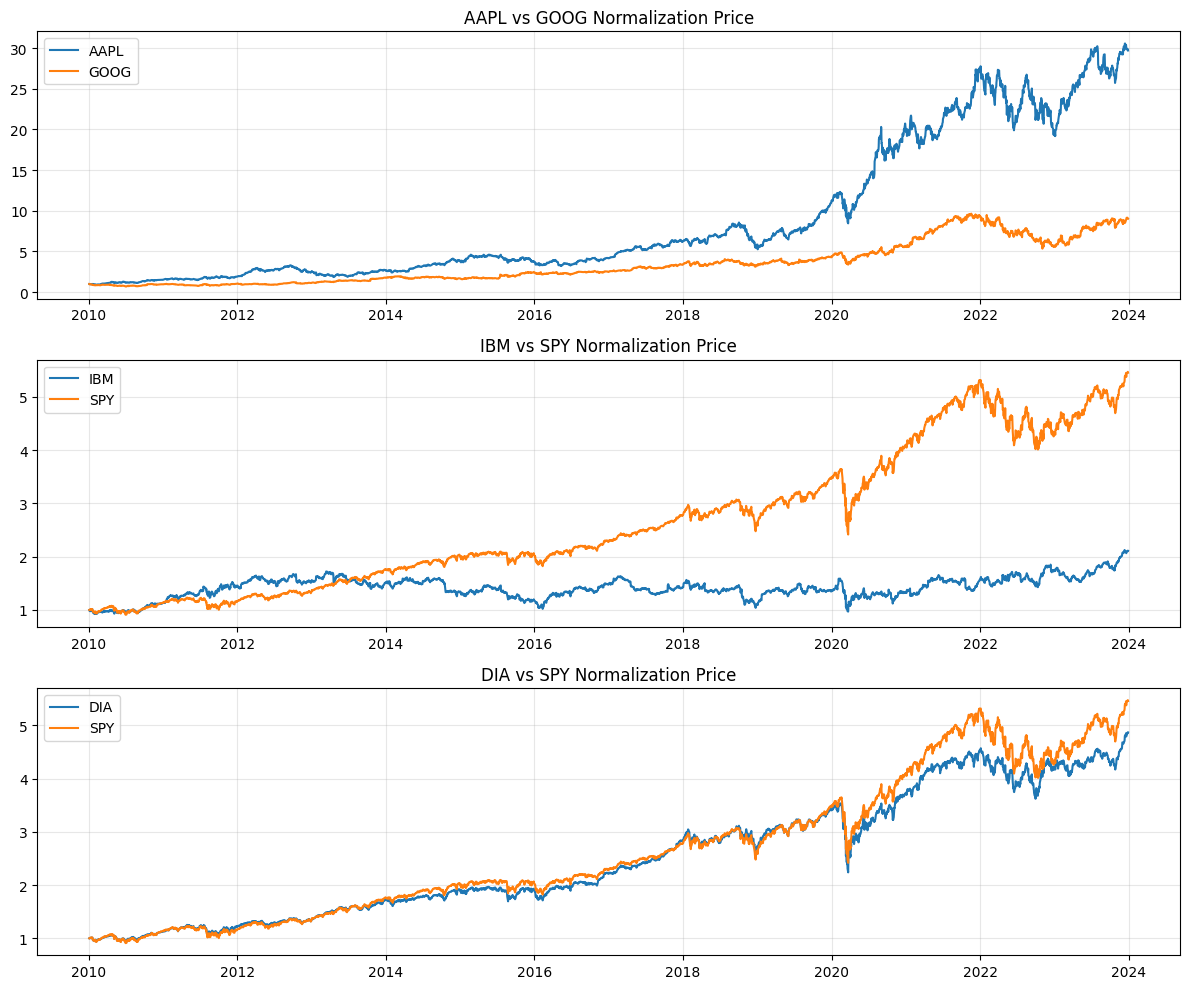

In [111]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax,(A,B) in zip(axes,PAIRS):
    key= f"{A}_{B}"
    df= pair_prices[key]
    normalized = df/df.iloc[0]
    ax.plot(normalized[A],label=A)
    ax.plot(normalized[B],label=B)
    ax.set_title(f"{A} vs {B} Normalization Price")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
!pip install arch --quiet

from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from arch import arch_model
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

^C


In [ ]:
def formation_distance(price_A,price_B):
  norm_A=price_A/price_A.iloc[0]
  norm_B=price_B/price_B.iloc[0]

  spread=norm_A-norm_B

  mu=spread.mean()
  sigma=spread.std()

  return {
      "mu": mu,
      "sigma": sigma,
      "spread": spread,
      "norm_A": norm_A,
      "norm_B": norm_B,
  }


def formation_cointegration(price_A,price_B):
  score,pvalue,_=coint(price_A, price_B)

  X=add_constant(price_A)
  result=OLS(price_B,X).fit()
  beta=result.params.iloc[1]

  spread=price_B-beta*price_A
  mu=spread.mean()
  sigma=spread.std()

  print(f"Cointegration test p-value: {pvalue:.4f}",
        "✓ Pass（p<0.05）" if pvalue < 0.05 else "✗ Insignificant")
  print(f"cointegration coefficients β = {beta:.4f}")

  return {
      "beta": beta,
      "mu": mu,
      "sigma": sigma,
      "pvalue": pvalue,
      "spread": spread,
  }
def fit_garch_margin(return_series):
  model=arch_model(return_series*100,vol='Garch',p=1,q=1,dist='normal',rescale=False)
  res=model.fit(disp='off')

  std_resid=res.std_resid.dropna()

  n=len(std_resid)
  ranks=stats.rankdata(std_resid)
  u=ranks/(n+1)

  return u,res

def copula_loglik(u1,u2,copula_type,theta):
  eps=1e-8
  u1=np.clip(u1,eps,1-eps)
  u2=np.clip(u2,eps,1-eps)

  if copula_type=='gaussian':
    rho=np.clip(theta,-0.999,0.999)
    x1=stats.norm.ppf(u1)
    x2=stats.norm.ppf(u2)
    ll=(-0.5*np.log(1-rho**2)-(rho**2*(x1**2+x2**2)-2*rho*x1*x2)/(2*(1-rho**2)))

  elif copula_type=='clayton':
    a=np.clip(theta,1e-4,50)
    ll=(np.log(1+a)+(-1-a)*np.log(u1*u2)+(-1/a-2)*np.log(u1**(-a)+u2**(-a)-1))

  elif copula_type=='gumbel':
      a=np.clip(theta,1.0001,50)
      lu1=-np.log(u1);lu2=-np.log(u2)
      s=lu1**a+lu2**a
      C=np.exp(-s**(1/a))
      ll=(np.log(C)+(1/a-2)*np.log(s)+(a-1)*(np.log(lu1)+np.log(lu2))-np.log(u1*u2)+np.log(s**(1/a) + a - 1))

  elif copula_type=='frank':
      a=theta
      num=-a*np.exp(-a*(u1+u2))*(np.exp(-a)-1)
      den=(np.exp(-a*u1)-1)*(np.exp(-a*u2)-1)+(np.exp(-a)-1)
      den=np.where(np.abs(den)<eps,eps,den)
      ll=np.log(np.abs(num/den)+eps)

  elif copula_type=='student_t':
      rho,nu=theta[0],max(theta[1],2.01)
      rho=np.clip(rho,-0.999,0.999)
      x1=stats.t.ppf(u1,nu)
      x2=stats.t.ppf(u2,nu)
      ll=(stats.t.logpdf(x1,nu)*0+np.log(stats.multivariate_normal.pdf(
                  np.column_stack([x1, x2]),
                  mean=[0,0],
                  cov=[[1,rho],[rho,1]]) + eps)
              - stats.norm.logpdf(x1) - stats.norm.logpdf(x2))

  return -np.sum(ll)

def fit_best_copula(u1, u2):
    candidates = {
        'gaussian':{'x0':[0.5],'bounds':[(-0.99,0.99)]},
        'clayton':{'x0':[1.0],'bounds':[(0.01,20)]},
        'gumbel':{'x0':[1.5],'bounds':[(1.01,20)]},
        'frank':{'x0':[1.0],'bounds':[(-20,20)]},
        'student_t':{'x0':[0.5,5.0],'bounds':[(-0.99,0.99),(2.1,30)]},
    }
    results={}
    for name,cfg in candidates.items():
        try:
            opt=minimize(lambda t:copula_loglik(u1,u2,name,t
                      if name=='student_t' else t[0]),
                      x0=cfg['x0'],bounds=cfg['bounds'],
                      method='L-BFGS-B')
            n_params=len(cfg['x0'])
            aic=2*n_params+2*opt.fun
            results[name]={'aic':aic,'params':opt.x,'nll':opt.fun}
        except:
            results[name]={'aic':np.inf,'params':None,'nll':np.inf}

    best = min(results,key=lambda k: results[k]['aic'])
    return best,results[best]['params'],results

def formation_copula(return_A, return_B):
    u1, garch_A = fit_garch_margin(return_A)
    u2, garch_B = fit_garch_margin(return_B)

    best_copula, params, all_results = fit_best_copula(u1, u2)

    for k,v in all_results.items():
        print(f"{k:12s}: {v['aic']:.2f}")

    return {
        "best_copula": best_copula,
        "params": params,
        "u1": u1, "u2": u2,
        "garch_A": garch_A,
        "garch_B": garch_B,
        "all_results": all_results,
    }



In [ ]:
formation_params={}

for (A,B) in PAIRS:
    key=f"{A}_{B}"
    print(f"\n{'='*50}")
    print(f"stock paris:{A}&{B}")
    print(f"{'='*50}")

    pA=pair_prices[key][A]
    pB=pair_prices[key][B]
    rA=pair_returns[key][A]
    rB=pair_returns[key][B]

    print("\n[Distance method]")
    dm=formation_distance(pA, pB)
    print(f" mean spread μ={dm['mu']:.4f},standard deviation σ={dm['sigma']:.4f}")

    print("\n[Cointegration method]")
    cg=formation_cointegration(pA, pB)

    print("\n[Copula method]")
    cp=formation_copula(rA, rB)

    formation_params[key]={"distance": dm,"cointegration": cg,"copula": cp}


In [ ]:
TRANSACTION_COST=0.002
def compute_pnl(position_series, price_A, price_B, beta=1.0):
  ret_A=price_A.pct_change().fillna(0)
  ret_B=price_B.pct_change().fillna(0)

  idx=position_series.index.intersection(ret_A.index)
  position_series=position_series.loc[idx]
  ret_A=ret_A.loc[idx]
  ret_B=ret_B.loc[idx]

  daily_pnl=position_series.shift(1)*(ret_A-beta*ret_B)

  trade_mask=(position_series.diff().abs()>0).values
  daily_pnl.iloc[trade_mask]-=TRANSACTION_COST
  return daily_pnl.fillna(0)

def trading_distance(price_A, price_B, formation_result, threshold=2.0):
  mu=formation_result["mu"]
  sigma=formation_result["sigma"]

  norm_A=price_A/price_A.iloc[0]
  norm_B=price_B/price_B.iloc[0]
  spread=norm_A-norm_B

  z=(spread-mu)/sigma

  position=pd.Series(0,index=price_A.index,dtype=float)
  current_pos=0

  for i in range(len(z)):
    zi=z.iloc[i]
    if current_pos==0:
        if zi>threshold: current_pos=-1
        elif zi<-threshold: current_pos=+1
    else:
        if current_pos==+1 and zi>=0: current_pos=0
        if current_pos==-1 and zi<=0: current_pos=0
    position.iloc[i]=current_pos

  pnl=compute_pnl(position,price_A,price_B)
  return {"position": position, "spread": spread,
          "z": z, "pnl": pnl}

def trading_cointegration(price_A,price_B,formation_result,threshold=2.0):
    beta=formation_result["beta"]
    mu=formation_result["mu"]
    sigma=formation_result["sigma"]

    spread=price_B-beta*price_A
    z=(spread-mu)/sigma

    position=pd.Series(0,index=price_A.index,dtype=float)
    current_pos=0

    for i in range(len(z)):
        zi=z.iloc[i]
        if current_pos==0:
            if zi>threshold: current_pos=-1
            elif zi<-threshold: current_pos=+1
        else:
            if current_pos==+1 and zi>=0: current_pos=0
            if current_pos==-1 and zi<=0: current_pos=0
        position.iloc[i]=current_pos

    pnl=compute_pnl(position,price_A,price_B,beta=beta)
    return {"position": position, "spread": spread,
            "z": z, "pnl": pnl, "beta": beta}

def copula_h_function(u1, u2, copula_type, params):
  eps=1e-8
  u1=np.clip(u1,eps,1-eps)
  u2=np.clip(u2,eps,1-eps)

  if copula_type=='gaussian':
      rho=np.clip(params[0],-0.999,0.999)
      x1=stats.norm.ppf(u1)
      x2=stats.norm.ppf(u2)
      h1=stats.norm.cdf((x1-rho*x2)/np.sqrt(1-rho**2))

  elif copula_type=='clayton':
      a=params[0]
      h1=u2**(-a-1)*(u1**(-a)+u2**(-a)-1)**(-1/a-1)

  elif copula_type=='gumbel':
      a=params[0]
      lu1=-np.log(u1);lu2=-np.log(u2)
      s=lu1**a+lu2**a
      C=np.exp(-s**(1/a))
      h1=C*s**(1/a-1)*lu2**(a-1)/u2

  elif copula_type=='frank':
      a=params[0]
      num=np.exp(-a*u2)*(np.exp(-a*u1)-1)
      den=(np.exp(-a*u1)-1)*(np.exp(-a*u2)-1)+(np.exp(-a)-1)
      h1=num/np.where(np.abs(den))

  elif copula_type=='student_t':
    rho,nu=params[0],max(params[1],2.01)
    rho=np.clip(rho,-0.999,0.999)
    x1=stats.t.ppf(u1,nu)
    x2=stats.t.ppf(u2,nu)
    h1=stats.t.cdf((x1-rho*x2)/np.sqrt((nu+x2**2)*(1-rho**2)/(nu+1)),nu+1)

  return np.clip(h1,eps,1-eps)

def trading_copula(return_A,return_B,price_A,price_B,formation_result,threshold=0.5):
  copula_type=formation_result["best_copula"]
  params=formation_result["params"]
  u1_form=formation_result["u1"]
  u2_form=formation_result["u2"]

  def empirical_cdf_transform(new_val,reference_series):
      return np.mean(reference_series<=new_val)

  n_days=len(return_A)
  M1=0.0
  M2=0.0
  current_pos=0

  position=pd.Series(0,index=return_A.index,dtype=float)
  M1_series=pd.Series(0.0,index=return_A.index)
  M2_series=pd.Series(0.0,index=return_A.index)
  h1_series=pd.Series(0.0,index=return_A.index)
  h2_series=pd.Series(0.0,index=return_A.index)

  for i in range(n_days):
    rA_i=return_A.iloc[i]
    rB_i=return_B.iloc[i]

    u1_i=empirical_cdf_transform(rA_i,u1_form)
    u2_i=empirical_cdf_transform(rB_i,u2_form)

    h1=float(copula_h_function(u1_i,u2_i,copula_type,params))
    h2=float(copula_h_function(u2_i,u1_i,copula_type,params))

    M1+=(h1-0.5)
    M2+=(h2-0.5)

    if current_pos==0:
        if M1>threshold and M2<-threshold:
            current_pos=-1

        elif M1<-threshold and M2>threshold:
            current_pos=+1
    else:

        if (current_pos==+1 and M1>=0 and M2<=0):
            current_pos=0;M1=0;M2=0
        if (current_pos==-1 and M1<=0 and M2>=0):
            current_pos=0;M1=0;M2=0

    position.iloc[i]=current_pos
    M1_series.iloc[i]=M1
    M2_series.iloc[i]=M2
    h1_series.iloc[i]=h1
    h2_series.iloc[i]=h2

  pnl=compute_pnl(position,price_A,price_B)
  return {"position": position,"pnl": pnl,
          "M1": M1_series, "M2": M2_series,
          "h1": h1_series, "h2": h2_series}

In [ ]:
from dateutil.relativedelta import relativedelta

In [ ]:
def run_single_window(pair_key,form_start,form_end,trade_start,trade_end):
  A,B=pair_key.split("_")

  pA_form = pair_prices[pair_key][A].loc[form_start : form_end]
  pB_form = pair_prices[pair_key][B].loc[form_start : form_end]
  rA_form = pair_returns[pair_key][A].loc[form_start : form_end]
  rB_form = pair_returns[pair_key][B].loc[form_start : form_end]

  pA_trade = pair_prices[pair_key][A].loc[trade_start : trade_end]
  pB_trade = pair_prices[pair_key][B].loc[trade_start : trade_end]
  rA_trade = pair_returns[pair_key][A].loc[trade_start : trade_end]
  rB_trade = pair_returns[pair_key][B].loc[trade_start : trade_end]

  if len(pA_form)<240 or len(pA_trade)<120:
      return None

  try:
      fp_dm=formation_distance(pA_form,pB_form)
      fp_cg=formation_cointegration(pA_form,pB_form)
      fp_cp=formation_copula(rA_form,rB_form)


      dm=trading_distance(pA_trade,pB_trade,fp_dm)
      cg=trading_cointegration(pA_trade,pB_trade,fp_cg)
      cp=trading_copula(rA_trade,rB_trade,pA_trade,pB_trade,fp_cp)

      return {
          "distance":dm["pnl"],
          "cointegration":cg["pnl"],
          "copula":cp["pnl"],
      }
  except Exception as e:
      print(f" ⚠ this window has an error: {e}")
      return None

def rolling_backtest(pair_key,start_year=2012, start_month=1,
          end_year=2023,end_month=6,formation_months=12,trading_months=6):

  windows=[]
  cursor=pd.Timestamp(year=start_year, month=start_month, day=1)
  end_dt=pd.Timestamp(year=end_year, month=end_month, day=1)

  while cursor<=end_dt:
      form_start = cursor - relativedelta(months=formation_months)
      form_end = cursor - relativedelta(days=1)
      trade_start = cursor
      trade_end = cursor + relativedelta(months=trading_months) - relativedelta(days=1)
      windows.append((form_start, form_end, trade_start, trade_end))
      cursor += relativedelta(months=1)

  print(f"in total {len(windows)} backtesting windows")

  all_pnl={"distance": [], "cointegration": [], "copula": []}

  for idx,(fs, fe, ts, te) in enumerate(windows):
      print(f" window {idx+1:3d}/{len(windows)}: "
            f"formation window {fs.date()}~{fe.date()} | "
            f"trade window {ts.date()}~{te.date()}", end="")

      result = run_single_window(pair_key, fs, fe, ts, te)

      if result is not None:
          for strat in all_pnl:
              all_pnl[strat].append(result[strat])
          print("✓")
      else:
          print("skip")

  def aggregate_pnl(pnl_list):
    if not pnl_list:
      return pd.Series(dtype=float)
    df = pd.concat(pnl_list,axis=1)
    return df.mean(axis=1).fillna(0)

  daily_pnl={s:aggregate_pnl(all_pnl[s]) for s in all_pnl}
  return daily_pnl


def performance_summary(daily_pnl_series, strategy_name=""):
  r=daily_pnl_series.dropna()
  if len(r)==0:
      return {}

  ann_ret=r.mean() * 252
  ann_std=r.std()*np.sqrt(252)
  sharpe=ann_ret/ann_std if ann_std > 0 else 0
  downside=r[r < 0].std() * np.sqrt(252)
  sortino=ann_ret/downside if downside > 0 else 0
  cum=(1+r).cumprod()
  drawdown=(cum-cum.cummax())/cum.cummax()
  max_dd=drawdown.min()
  win_rate=(r>0).mean()

  metrics = {
      "method": strategy_name,
      "annualized return": f"{ann_ret*100:.2f}%",
      "annualized volatility": f"{ann_std*100:.2f}%",
      "Sharpe": f"{sharpe:.3f}",
      "Sortino": f"{sortino:.3f}",
      "max drawdown": f"{max_dd*100:.2f}%",
      "daily win rate": f"{win_rate*100:.1f}%",
  }
  return metrics




In [ ]:
backtest_results={}

for (A,B) in PAIRS:
  key=f"{A}_{B}"
  print(f"\n{'='*55}")
  print(f"  开始回测：{A} & {B}")
  print(f"{'='*55}")

  daily_pnl=rolling_backtest(key,
      start_year=2012,start_month=1,
      end_year=2016,end_month=12,)
  backtest_results[key]=daily_pnl

  rows=[]
  for strat in ["distance","cointegration","copula"]:
      rows.append(performance_summary(daily_pnl[strat],strat))
  summary_df=pd.DataFrame(rows).set_index("method")
  print(f"\n── {A}&{B} performance summary ──")
  print(summary_df.to_string())

  fig,ax=plt.subplots(figsize=(13, 4))
  colors={"distance": "steelblue",
      "cointegration": "darkorange",
      "copula": "green"}
  labels={"distance": "distance method",
      "cointegration": "cointegration method",
      "copula": "Copula method"}

  for strat,pnl in daily_pnl.items():
      pnl.cumsum().plot(ax=ax,label=labels[strat],
              color=colors[strat], lw=1.2)

  ax.axhline(0, color="black", ls=":", lw=0.8)
  ax.set_title(f"{A} & {B} — rolling backtest cummulative PnL")
  ax.set_ylabel("Cummulative PnL")
  ax.legend()
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(f"backtest_{key}.png", dpi=150)
  plt.show()



In [ ]:
def compute_metrics(daily_pnl, rf_annual=0.02):
  r = daily_pnl.dropna().replace([np.inf, -np.inf], 0)
  rf = rf_annual / 252
  er = r - rf
  n = len(r)

  if n == 0:
      return {}

  ann_ret = r.mean() * 252
  ann_exc_ret = er.mean() * 252
  ann_std = r.std() * np.sqrt(252)
  total_ret = (1 + r).prod() - 1

  sharpe = ann_exc_ret / ann_std if ann_std > 0 else 0

  downside_r  = r[r < rf]
  downside_std = downside_r.std() * np.sqrt(252) if len(downside_r) > 0 else 1e-8
  sortino     = ann_exc_ret / downside_std

  cum  = (1+r).cumprod()
  rolling_max = cum.cummax()
  drawdown  = (cum - rolling_max) / rolling_max
  max_dd= drawdown.min()

  in_drawdown = drawdown < 0
  dd_duration = 0
  max_dd_dur  = 0
  for v in in_drawdown:
    if v:
        dd_duration += 1
        max_dd_dur   = max(max_dd_dur, dd_duration)
    else:
        dd_duration  = 0

  win_rate= (r > 0).mean()
  pos_days= (r > 0).sum()
  neg_days= (r < 0).sum()
  avg_win= r[r > 0].mean() if pos_days > 0 else 0
  avg_loss= r[r < 0].mean() if neg_days > 0 else 0
  profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

  return {
      "annualized extra return": ann_exc_ret,
      "annualized return":  ann_ret,
      "cummulative return": total_ret,
      "annualized volatility": ann_std,
      "Sharpe ratio":  sharpe,
      "Sortino ratio": sortino,
      "max drawdown":  max_dd,
      "maximum drawdown duration (days)": max_dd_dur,
      "daily win rate":  win_rate,
      "profit factor":  profit_factor,
      "observation days":  n,
  }

def print_summary_table(backtest_results):
  fmt = {
      "annualized extra return":    lambda x: f"{x*100:+.2f}%",
      "annualized return":      lambda x: f"{x*100:+.2f}%",
      "cummulative return":      lambda x: f"{x*100:+.2f}%",
      "annualized volatility":      lambda x: f"{x*100:.2f}%",
      "Sharpe ratio":      lambda x: f"{x:.3f}",
      "Sortino ratio":     lambda x: f"{x:.3f}",
      "max drawdown":        lambda x: f"{x*100:.2f}%",
      "maximum drawdown duration (days)": lambda x: f"{int(x)}days",
      "daily win rate":          lambda x: f"{x*100:.1f}%",
      "profit factor":          lambda x: f"{x:.2f}",
      "observation days":        lambda x: f"{int(x)}days",
  }

  for pair_key, daily_pnl in backtest_results.items():
    A, B = pair_key.split("_")
    print(f"\n{'═'*60}")
    print(f"  {A} & {B} — Evaluation Summary")
    print(f"{'═'*60}")

    rows = {}
    for strat, pnl in daily_pnl.items():
        rows[strat] = compute_metrics(pnl)

    df = pd.DataFrame(rows).T
    for col in df.columns:
      if col in fmt:
          df[col] = df[col].apply(fmt[col])
    print(df.to_string())


def plot_full_evaluation(backtest_results):
  colors = {
      "distance": "steelblue",
      "cointegration": "darkorange",
      "copula": "green",
  }


  for pair_key, daily_pnl in backtest_results.items():
    A, B = pair_key.split("_")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{A} & {B} — Evaluation Summary", fontsize=14)

    ax = axes[0, 0]
    for strat, pnl in daily_pnl.items():
      cum = (1 + pnl).cumprod()
      cum.plot(ax=ax, label=strat,
                color=colors[strat], lw=1.2)
    ax.axhline(1, color="black", ls=":", lw=0.8)
    ax.set_title("cummulative return（starting from $1）")
    ax.set_ylabel("net value")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


    ax = axes[0, 1]
    for strat, pnl in daily_pnl.items():
      cum= (1 + pnl).cumprod()
      drawdown = (cum - cum.cummax()) / cum.cummax()
      drawdown.plot(ax=ax, label=strat,
                    color=colors[strat], lw=0.8)
    ax.fill_between(drawdown.index, drawdown, 0,
                    alpha=0.05, color="red")
    ax.set_title("Drawdown Curve")
    ax.set_ylabel("Drawdown")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


    ax = axes[1, 0]
    for strat, pnl in daily_pnl.items():
      roll_sharpe = (pnl.rolling(252).mean()
                      / pnl.rolling(252).std()) * np.sqrt(252)
      roll_sharpe.plot(ax=ax, label=strat,
                        color=colors[strat], lw=0.9)
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.axhline(1, color="gray",  ls="--", lw=0.6, label="Sharpe=1")
    ax.set_title("1-year rolling sharpe ratio")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


    ax = axes[1, 1]
    monthly_data = []
    monthly_labels = []
    for strat, pnl in daily_pnl.items():
      monthly = pnl.resample("ME").sum()
      monthly_data.append(monthly.values)
      monthly_labels.append(strat)
    bp = ax.boxplot(monthly_data, labels=monthly_labels, patch_artist=True)
    for patch, strat in zip(bp["boxes"], daily_pnl.keys()):
      patch.set_facecolor(colors[strat])
      patch.set_alpha(0.6)
    ax.axhline(0, color="black", ls=":", lw=0.8)
    ax.set_title("monthly return distribution")
    ax.set_ylabel("monthly return")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(f"evaluation_{pair_key}.png", dpi=150)
    plt.show()

In [ ]:
def plot_cross_pair_comparison(backtest_results):

  pair_labels = [k.replace("_", " & ") for k in backtest_results.keys()]
  strategies = ["distance","cointegration","copula"]
  colors= ["steelblue", "darkorange", "green"]

  sharpe_data  = {s: [] for s in strategies}
  ret_data  = {s: [] for s in strategies}

  for pair_key, daily_pnl in backtest_results.items():
    for strat in strategies:
      m = compute_metrics(daily_pnl[strat])
      sharpe_data[strat].append(m.get("Sharpe ratio", 0))
      ret_data[strat].append(m.get("annualized return", 0) * 100)

  x = np.arange(len(pair_labels))
  width = 0.25

  fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle("Cross pairs Comparison", fontsize=13)

  for i, (strat, c) in enumerate(zip(strategies, colors)):
    offset = (i - 1) * width
    ax1.bar(x + offset, sharpe_data[strat], width,
            label=strat, color=c, alpha=0.8)
    ax2.bar(x + offset, ret_data[strat], width,
            label=strat, color=c, alpha=0.8)

  for ax, title, ylabel in [
      (ax1, "Sharpe ratio Comparison", "Sharpe"),
      (ax2, "Annualized excess return Comparison", "Annualized Excess return(%)"),
  ]:
    ax.set_xticks(x); ax.set_xticklabels(pair_labels)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

  plt.tight_layout()
  plt.show()


# ════════════════════════════════════════════════════════════
# 运行所有评估
# ════════════════════════════════════════════════════════════
print("▶ Valuation Summary")
print_summary_table(backtest_results)

print("\n▶ Fout Plots")
plot_full_evaluation(backtest_results)

print("\n▶ Cross Pair Comparison")
plot_cross_pair_comparison(backtest_results)



# Additional Exploration
I try to find the best pair among SP500, instead of fixed 3 pairs

In [ ]:
from itertools import combinations

In [ ]:
def get_sp500_tickers():
  import urllib.request
  url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
  req = urllib.request.Request(url, headers={
      "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 Chrome/120.0 Safari/537.36"
  })
  html = urllib.request.urlopen(req).read()
  table = pd.read_html(html)[0]
  tickers = [t.replace(".", "-") for t in table["Symbol"].tolist()]
  print(f"S&P500 total stocks：{len(tickers)}")
  return tickers

tickers = get_sp500_tickers()

In [ ]:
START = "2010-01-01"
END   = "2023-12-31"
TOP_N = 5
raw = yf.download(tickers, start=START, end=END,
                  auto_adjust=True, progress=False)
all_prices = raw["Close"]

threshold  = 0.95
valid_cols = all_prices.columns[
    all_prices.notna().mean() >= threshold
]
all_prices = all_prices[valid_cols].ffill()
print(f"Valid Stocks：{len(valid_cols)}，"
      f"dataset dimensions：{all_prices.shape}")

In [ ]:
def compute_top_pairs_vectorized(price_df, top_n=5):
  normed = price_df / price_df.iloc[0]
  M=normed.values
  T,N=M.shape

  ss=(M ** 2).sum(axis=0)

  cross=M.T@M
  ssd_matrix=(ss[:, None] + ss[None, :]- 2 * cross)

  tickers_arr=price_df.columns.tolist()
  rows,cols = np.triu_indices(N, k=1)
  ssd_values = ssd_matrix[rows, cols]

  actual_n=min(top_n,len(ssd_values))
  top_idx = np.argpartition(ssd_values, top_n)[:actual_n]
  top_idx = top_idx[np.argsort(ssd_values[top_idx])]

  pairs = [(tickers_arr[rows[i]], tickers_arr[cols[i]],
            ssd_values[i])
            for i in top_idx]
  return pairs   # [(tickerA, tickerB, ssd), ...

In [ ]:
def run_window_dynamic(form_start, form_end,
            trade_start, trade_end,
              top_n=5):

  p_form=all_prices.loc[form_start:form_end].dropna(axis=1)
  p_trade=all_prices.loc[trade_start:trade_end]

  if len(p_form)<240 or len(p_trade)<120:
      return None

  candidates=compute_top_pairs_vectorized(p_form,top_n=top_n*5)
  top_pairs_dm_cp=candidates[:top_n]

  top_pairs_cg=[]
  for (A, B, ssd) in candidates:
    if len(top_pairs_cg) >= top_n:
        break
    if A not in p_form.columns or B not in p_form.columns:
        continue
    try:
        from statsmodels.tsa.stattools import coint
        _, pvalue, _ = coint(p_form[A], p_form[B])
        if pvalue < 0.05:
            top_pairs_cg.append((A, B, ssd))

    except:
        continue

  if not top_pairs_cg:
    print("Can't find any pair cointegrated significantly, skip this window")


  pnl_dm_list = []
  pnl_cg_list = []
  pnl_cp_list = []

  for (A, B, ssd) in top_pairs_dm_cp:
    if A not in p_trade.columns or B not in p_trade.columns:
      continue

    pA_f = p_form[A]; pB_f = p_form[B]
    pA_t = p_trade[A]; pB_t = p_trade[B]
    fp_dm = formation_distance(pA_f, pB_f)
    dm  = trading_distance(pA_t, pB_t, fp_dm)
    pnl_dm_list.append(dm["pnl"])

  for (A, B, ssd) in top_pairs_cg:
    if A not in p_trade.columns or B not in p_trade.columns:
      continue
    pA_f = p_form[A];  pB_f = p_form[B]
    pA_t = p_trade[A]; pB_t = p_trade[B]
    fp_cg = formation_cointegration(pA_f, pB_f)
    cg    = trading_cointegration(pA_t, pB_t, fp_cg)
    pnl_cg_list.append(cg["pnl"])

  for (A, B, ssd) in top_pairs_dm_cp:
    if A not in p_trade.columns or B not in p_trade.columns:
      continue
    pA_f = p_form[A];  pB_f = p_form[B]
    pA_t = p_trade[A]; pB_t = p_trade[B]
    rA_f = np.log(pA_f/pA_f.shift(1)).dropna()
    rB_f = np.log(pB_f/pB_f.shift(1)).dropna()
    rA_t = np.log(pA_t/pA_t.shift(1)).dropna()
    rB_t = np.log(pB_t/pB_t.shift(1)).dropna()
    fp_cp = formation_copula(rA_f, rB_f)
    cp  = trading_copula(rA_t, rB_t, pA_t, pB_t, fp_cp)
    pnl_cp_list.append(cp["pnl"])

  def mean_pnl(lst):
    if not lst:
      return pd.Series(0, index=p_trade.index, dtype=float)
    df = pd.concat(lst, axis=1)
    return df.mean(axis=1).fillna(0)

  return {
      "distance":      mean_pnl(pnl_dm_list),
      "cointegration": mean_pnl(pnl_cg_list),
      "copula":        mean_pnl(pnl_cp_list),
  }

In [ ]:
def rolling_backtest_sp500(
        start_year=2012, start_month=1,
        end_year=2014,   end_month=12,
        formation_months=12, trading_months=6,
        top_n=5):

  cursor = pd.Timestamp(year=start_year, month=start_month, day=1)
  end_dt = pd.Timestamp(year=end_year,   month=end_month,   day=1)

  all_pnl = {"distance": [], "cointegration": [], "copula": []}
  win_idx = 0

  while cursor <= end_dt:
    win_idx    += 1
    form_start  = cursor - relativedelta(months=formation_months)
    form_end    = cursor - relativedelta(days=1)
    trade_start = cursor
    trade_end   = cursor + relativedelta(months=trading_months) \
                          - relativedelta(days=1)

    print(f"\nWindow{win_idx}: Formation Period {form_start.date()}~{form_end.date()}"
          f" | Trade Period {trade_start.date()}~{trade_end.date()}")

    result = run_window_dynamic(
        form_start, form_end, trade_start, trade_end, top_n
    )

    if result is not None:
        for s in all_pnl:
            all_pnl[s].append(result[s])
        print(f"  ✓ Done")
    else:
        print(f"  skip")

    cursor += relativedelta(months=1)

  def agg(lst):
    if not lst: return pd.Series(dtype=float)
    return pd.concat(lst, axis=1).mean(axis=1).fillna(0)

  return {s: agg(all_pnl[s]) for s in all_pnl}

In [ ]:
sp500_pnl = rolling_backtest_sp500(
    start_year=2012, start_month=1,
    end_year=2014,   end_month=12,
    top_n=TOP_N,
)

In [ ]:
print("\n▶ Valuation Summary")

rows = []
for s, pnl in sp500_pnl.items():
  m = compute_metrics(pnl)
  m["method"] = s
  rows.append(m)
summary = pd.DataFrame(rows).set_index("method")
print(summary[["annualized extra return","Sharpe ratio",
               "Sortino ratio","max drawdown","daily win rate"]].to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
colors  = {"distance":"steelblue",
           "cointegration":"darkorange",
           "copula":"green"}
for s, pnl in sp500_pnl.items():
    pnl.cumsum().plot(ax=ax, label=s,
                      color=colors[s], lw=1.2)
ax.axhline(0, color="black", ls=":", lw=0.8)
ax.set_title("S&P500 Dynamic Pairs — PnL of 3 Methods（Top5 pairs，transaction cost included）")
ax.set_ylabel("Cummulative return"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sp500_backtest.png", dpi=150)
plt.show()
print("\n✓ Done")